In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import bayesian_stats_course_tools

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Urn example

In [45]:
def binomial(n,p):
    return scipy.stats.Binomial(n=n,p=p)

def urn_prior(n,r):
    return 1/(n+1)*np.ones_like(r)

def urn_likelyhood(r,n,t,k):
    theta=r/n
    return scipy.special.binom(t,k)*theta**k *(1-theta)**(t-k)

def urn_posterior(r,n,t,k):
    return urn_likelyhood(r,n,t,k)*urn_prior(n,r)

def normalize(arr):
    return arr/np.sum(arr)

def simulate_urn(n,t,k):
    r=np.arange(1,n+1)
    post=urn_posterior(r,n,t,k)
    post=normalize(post)
    # plt.plot(r,post, label=f"posterior, k={k},t={t}.4f,n={n}")
    # plt.xlabel("r")
    # plt.ylabel("$P$")
    # plt.legend()
    return r,post



In [39]:
# a=binomial(10,0.34)
urn_likelyhood(2,10,5,2)

np.float64(0.2048000000000001)

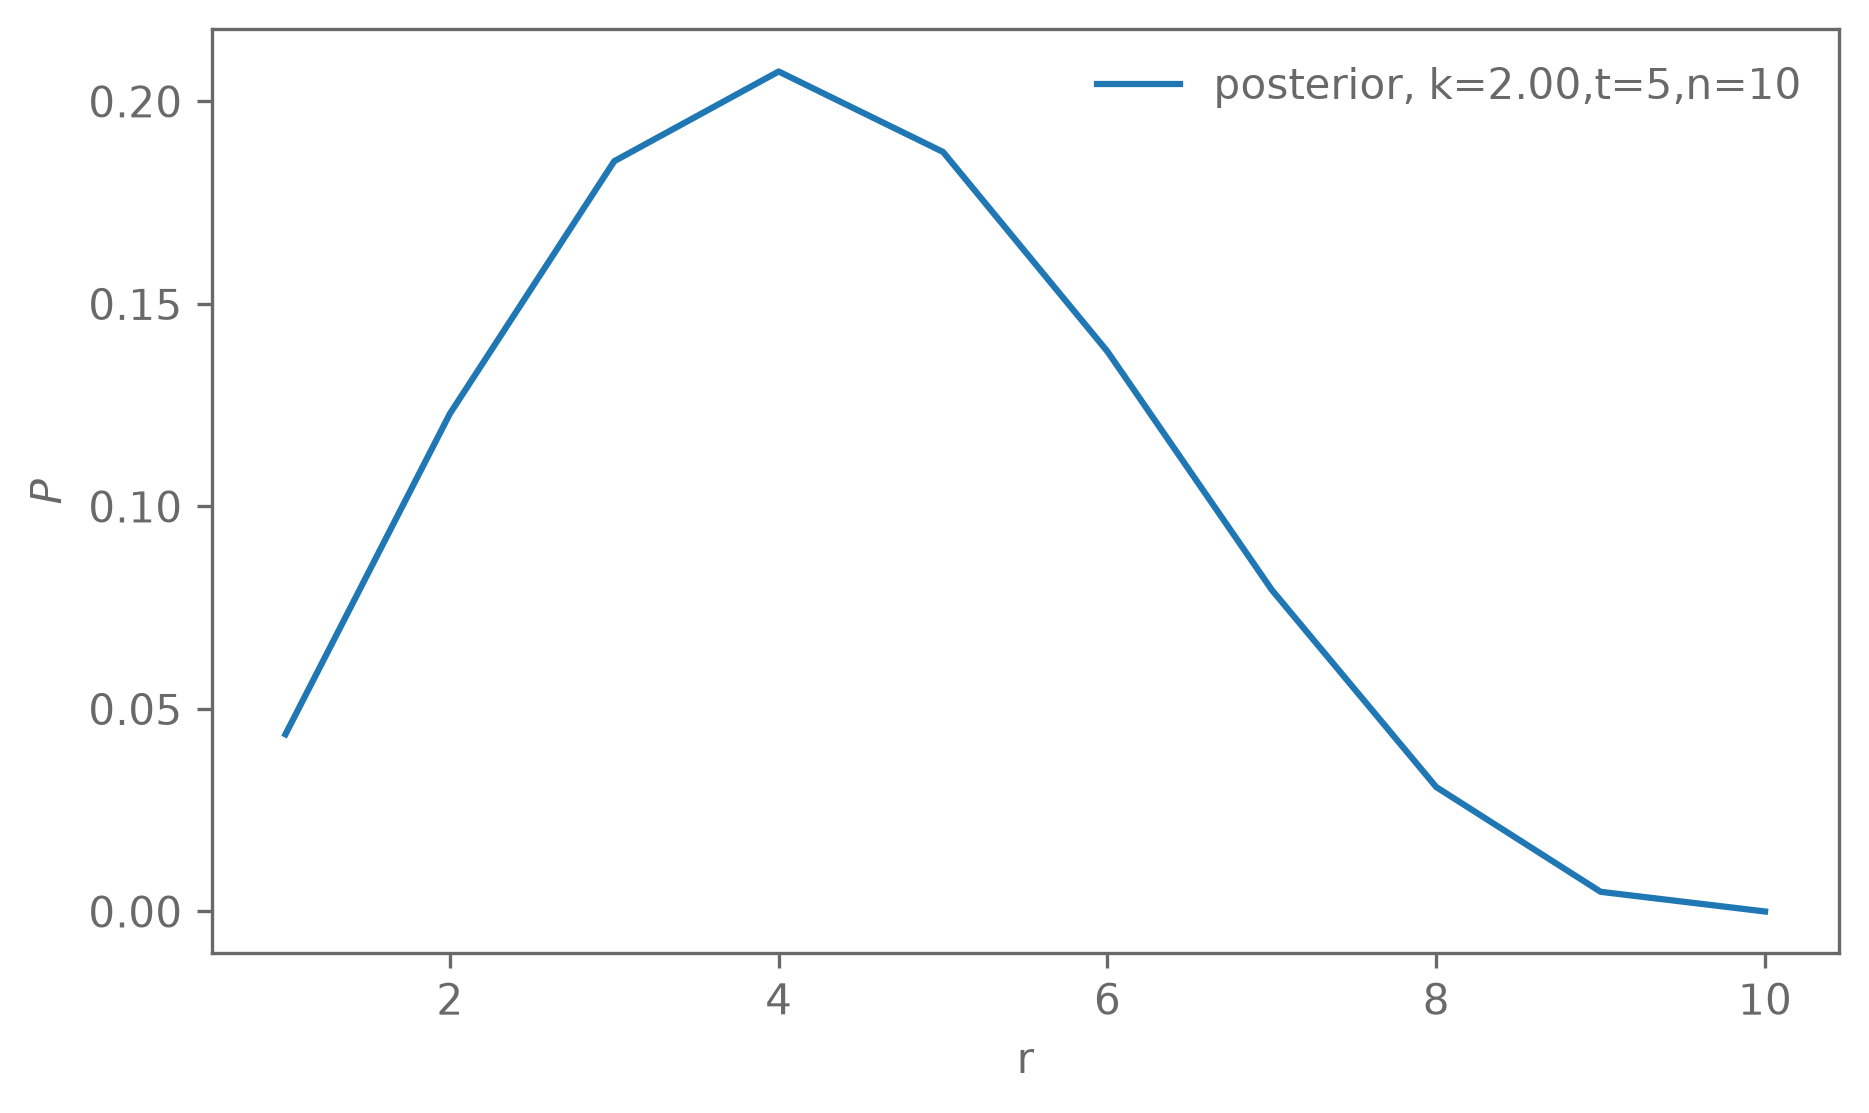

In [44]:
n=10
t=5
k=2
r=np.arange(1,n+1)
post=urn_posterior(r,n,t,k)
post=normalize(post)
plt.plot(r,post, label=f"posterior, k={k:.2f},t=5,n=10")
plt.xlabel("r")
plt.ylabel("$P$")
plt.legend()

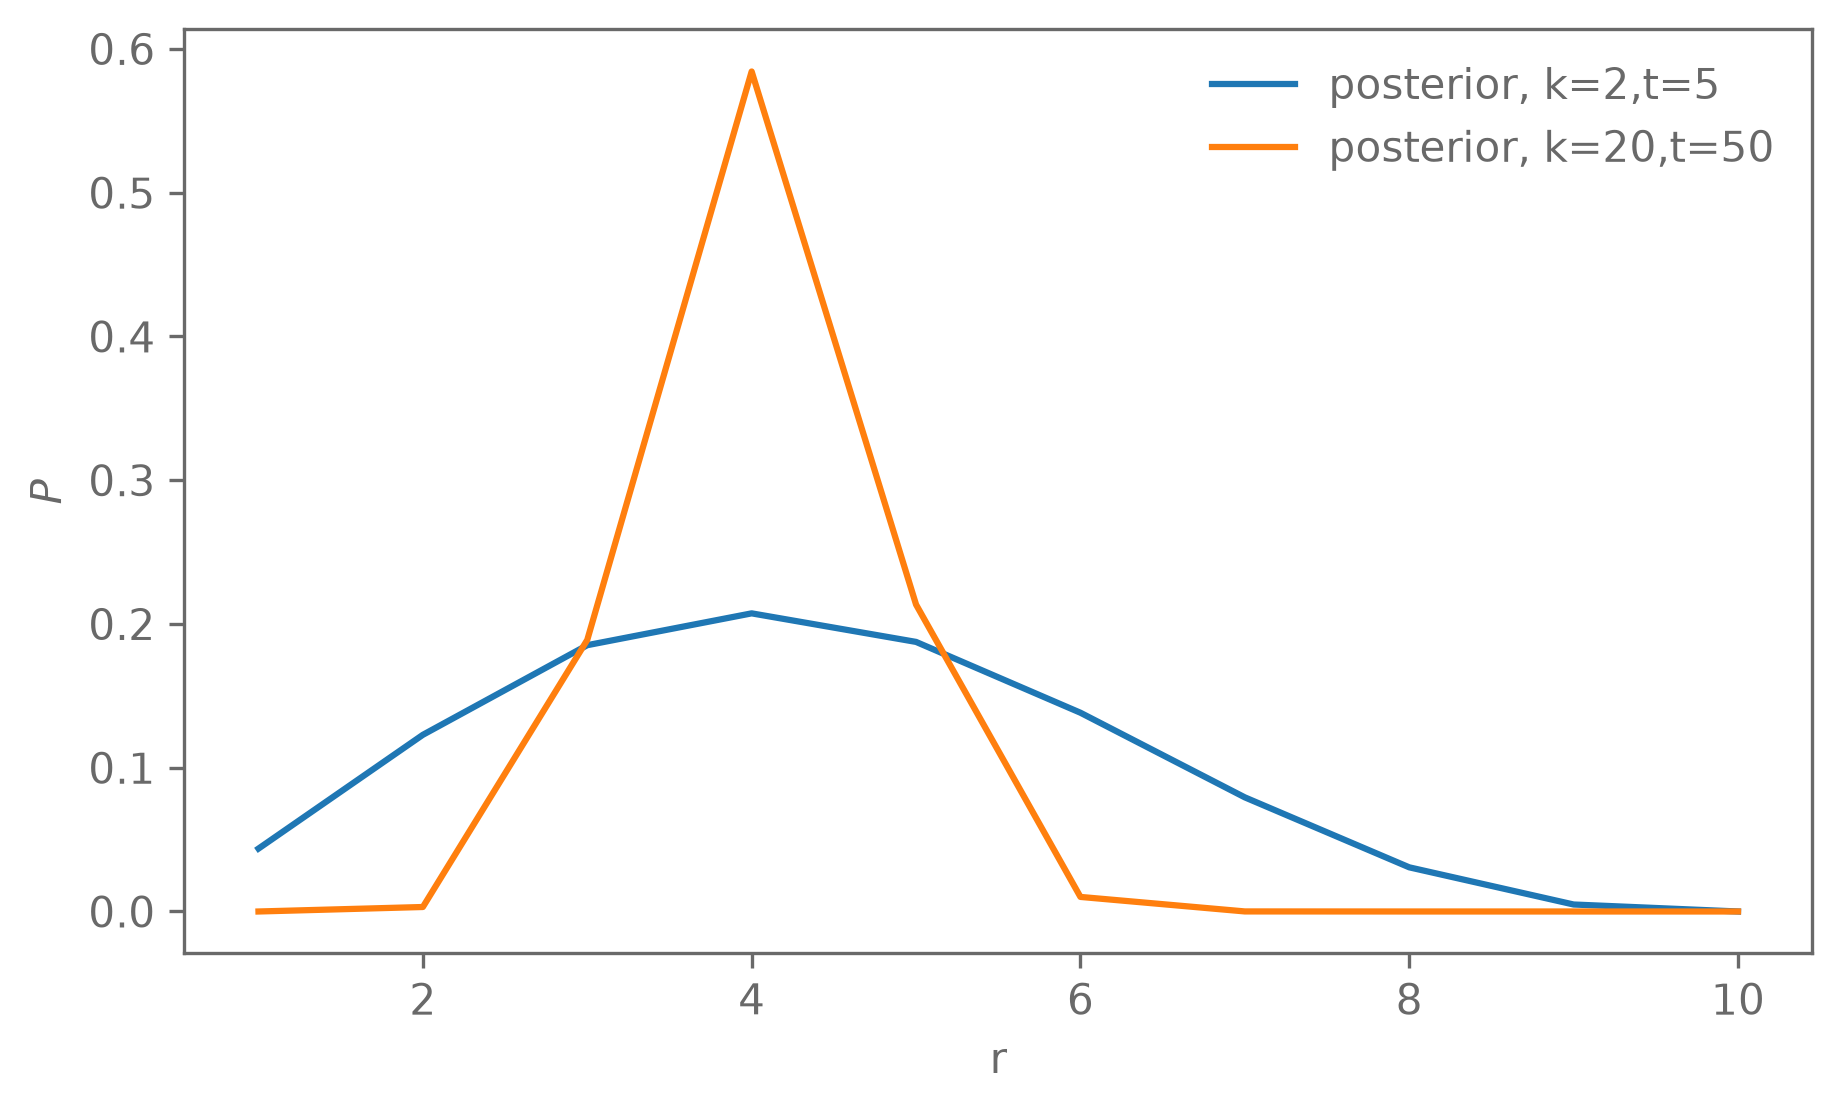

In [47]:
r1,post1=simulate_urn(n=10,t=50,k=20)
r2,post2=simulate_urn(10,5,2)

plt.plot(r1,post2, label="posterior, k=2,t=5")
plt.plot(r1,post1, label="posterior, k=20,t=50")
plt.xlabel("r")
plt.ylabel("$P$")
plt.legend()

## Update the prior

In [49]:
def update_prior(r,n,t,k):
    return urn_posterior(r,n,t,k)
def update_posterior(r,n,t,k):
    return urn_likelyhood(r,n,t,k,)*update_prior(r,n,t,k)

In [ ]:
r1,post1=simulate_urn(n=10,t=5,k=2)
r2,post2=simulate_urn(n=10,t=50,k=20)
post3=normalize(update_posterior(r1,n=10,t=5,k=2))
post4=normalize(update_posterior(r1,n=10,t=50,k=20))

Text(0, 0.5, '$P$')

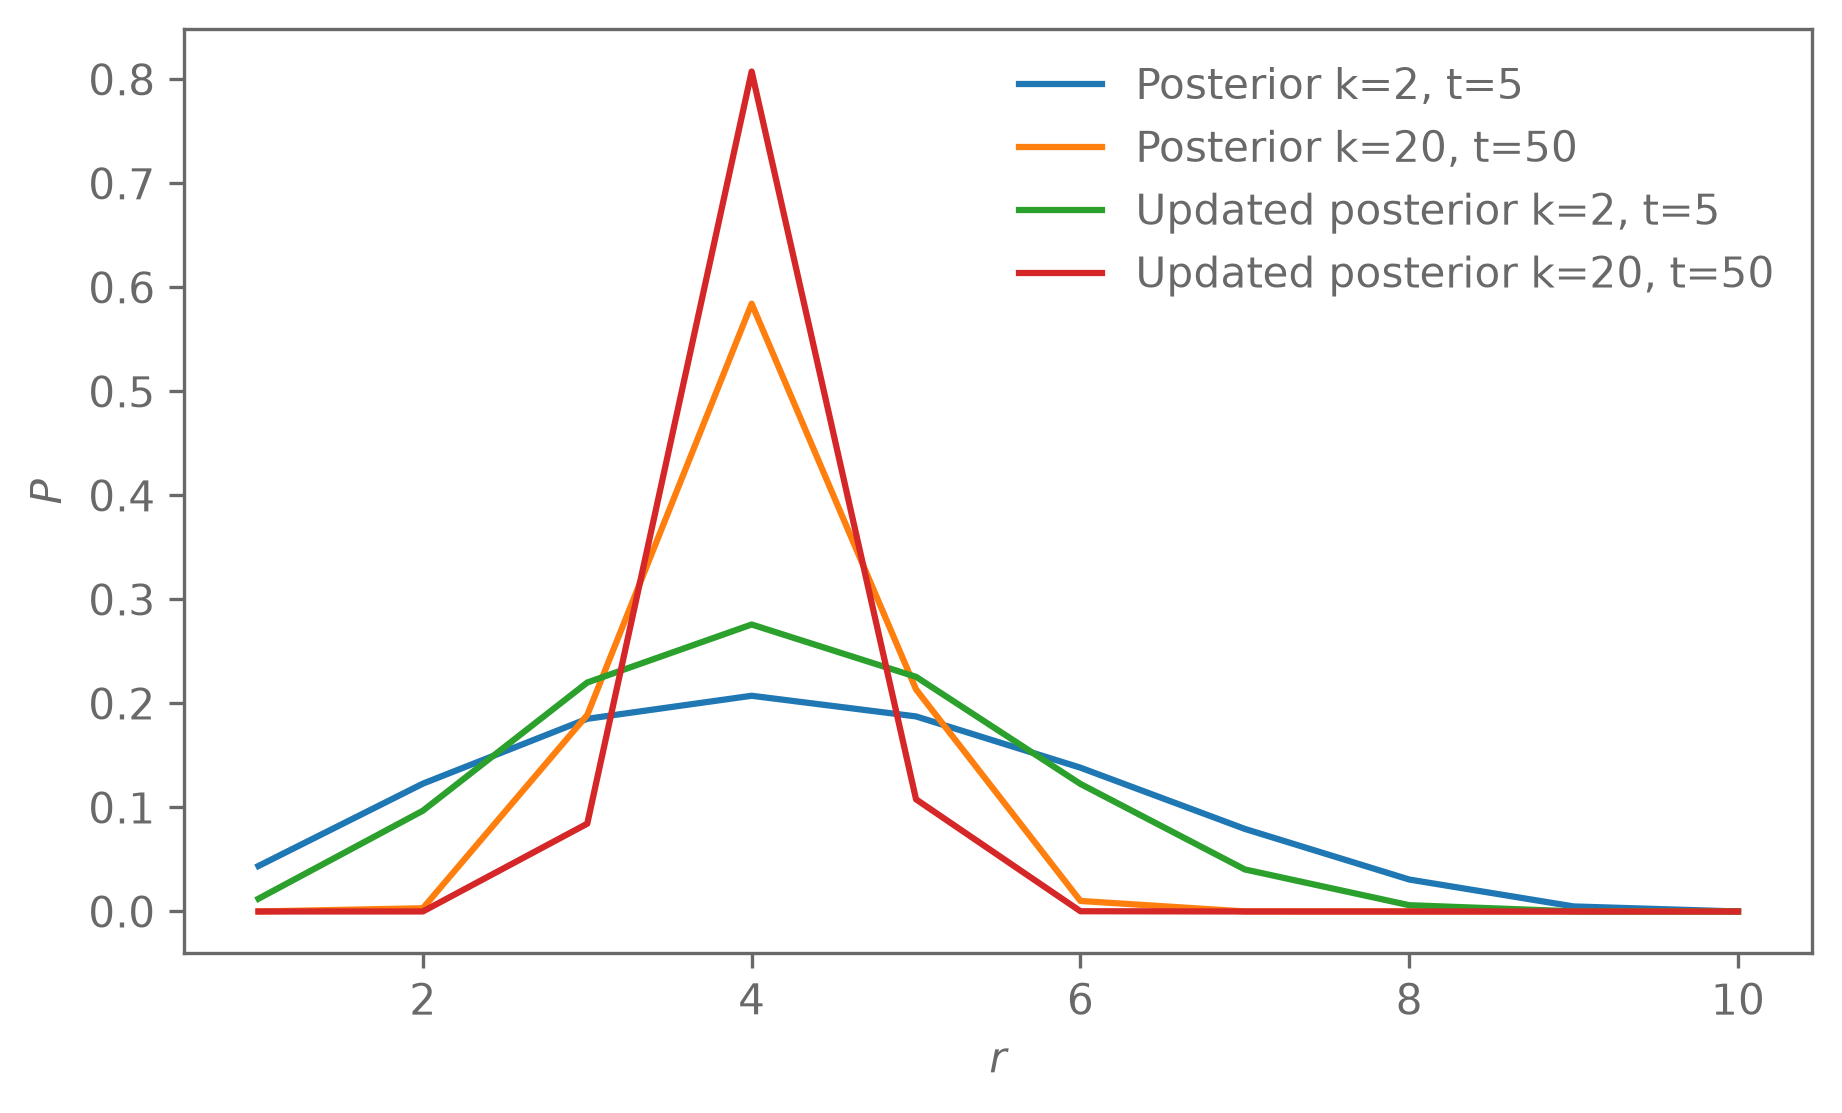

In [51]:
plt.plot(r1,post1,label="Posterior k=2, t=5")
plt.plot(r1,post2,label="Posterior k=20, t=50")
plt.plot(r1,post3,label="Updated posterior k=2, t=5")
plt.plot(r1,post4,label="Updated posterior k=20, t=50")
plt.legend()
plt.xlabel("$r$")
plt.ylabel("$P$")

# Model comparison

In [78]:
# generate model data as currently non is available
def generate_model_data_linear():
    a,b,n=2,3,20
    f = lambda x: a*x+b
    x=np.random.random(size=n)*20
    yerr= np.random.normal(0,1,size=n)*5
    sigma_y=np.mean(np.absolute(yerr))
    y= f(x) + yerr
    return x,y, sigma_y

<ErrorbarContainer object of 3 artists>

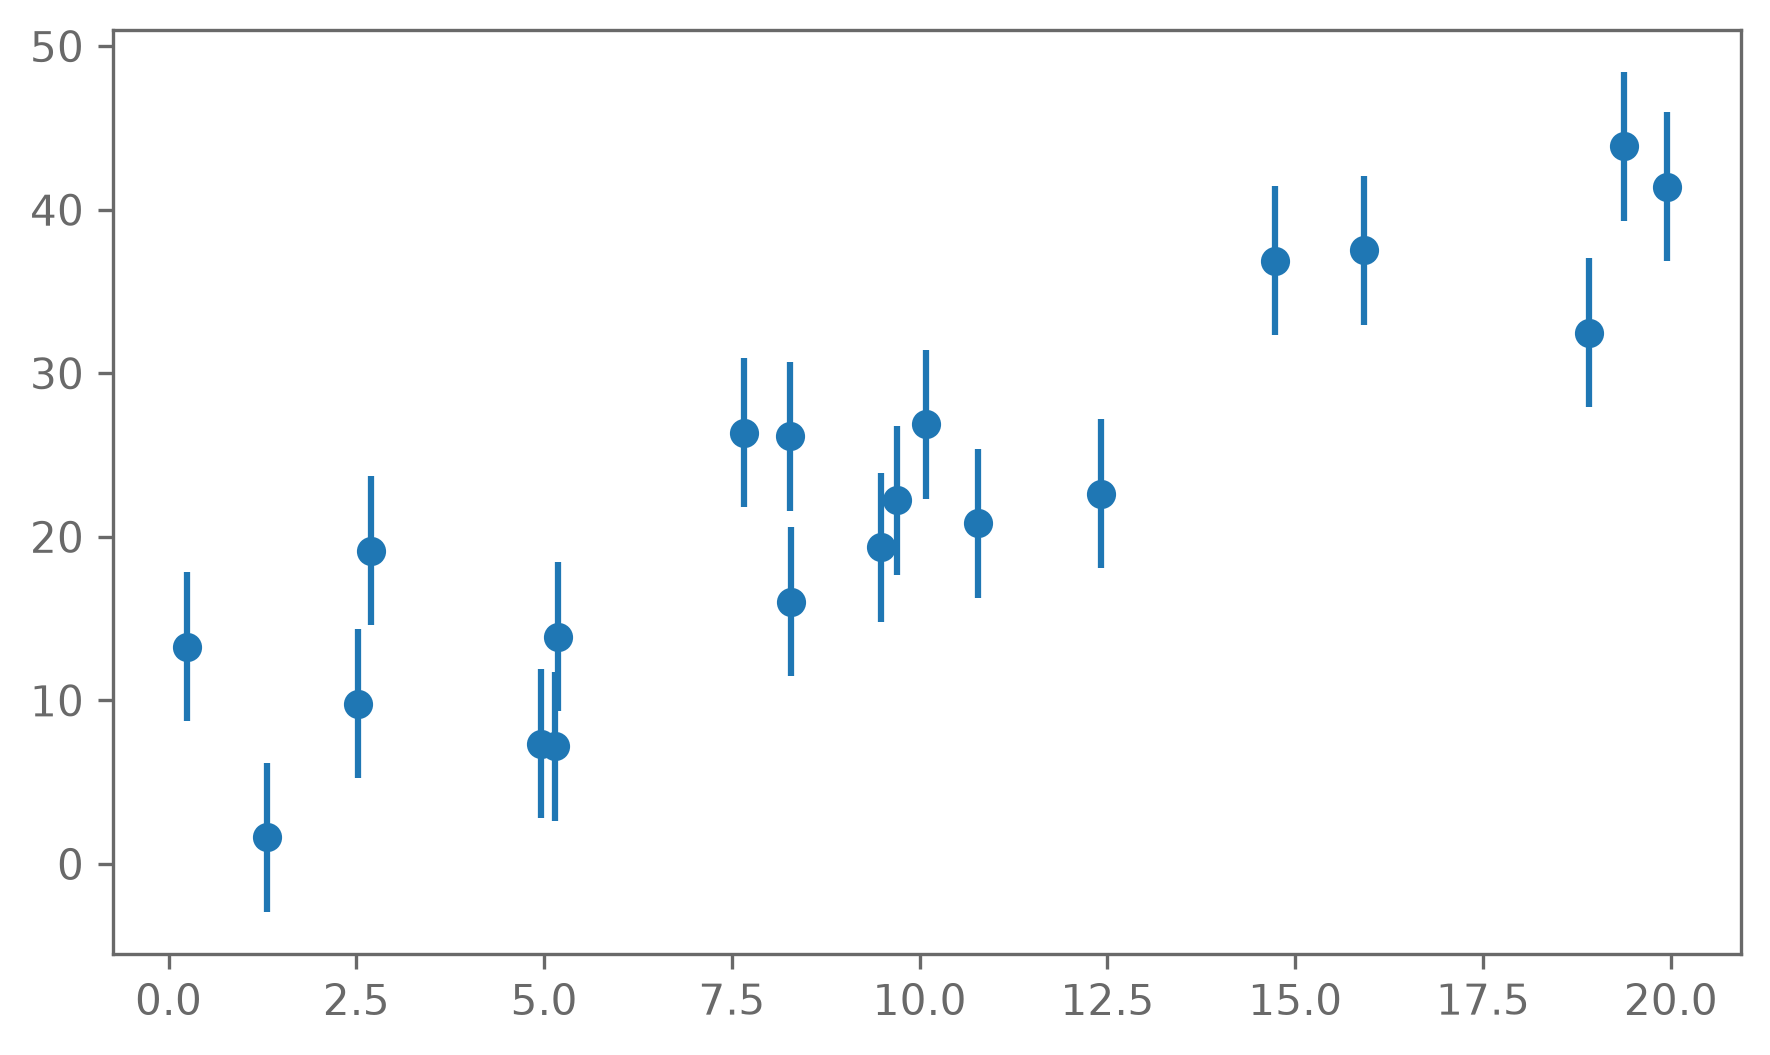

In [79]:
x,y,yerr=generate_model_data_linear()
plt.errorbar(x,y,yerr=np.ones_like(x)*yerr, fmt="o")

In [111]:
def model(m,b,x):
    return m*x+b

def log_likelihood_probability(y,m,b,x,yerr):
    prediction=model(m,b,x)
    n=len(y)
    return (-0.5* np.sum((y-prediction)**2 / yerr**2) -n/2*np.log(2*np.pi*yerr**2))

In [85]:
priorm=scipy.stats.norm(loc=1,scale=1)
priorb=scipy.stats.norm(loc=0,scale=1.2)

def log_prior_probability(m,b):
    return priorm.logpdf(m) + priorb.logpdf(b)

In [92]:
def sample_prior(n_sample):
    """Sample n_sample times from the prior distribution."""
    return np.vstack((priorm.rvs(n_sample), priorb.rvs(n_sample))).T
np.random.seed(42)
prior_model_predictive = np.array(
[model(*parameters, x) for parameters in sample_prior(n_sample=20)]
)

In [86]:
log_prior_probability(1,1)

np.float64(-2.3674208454255226)

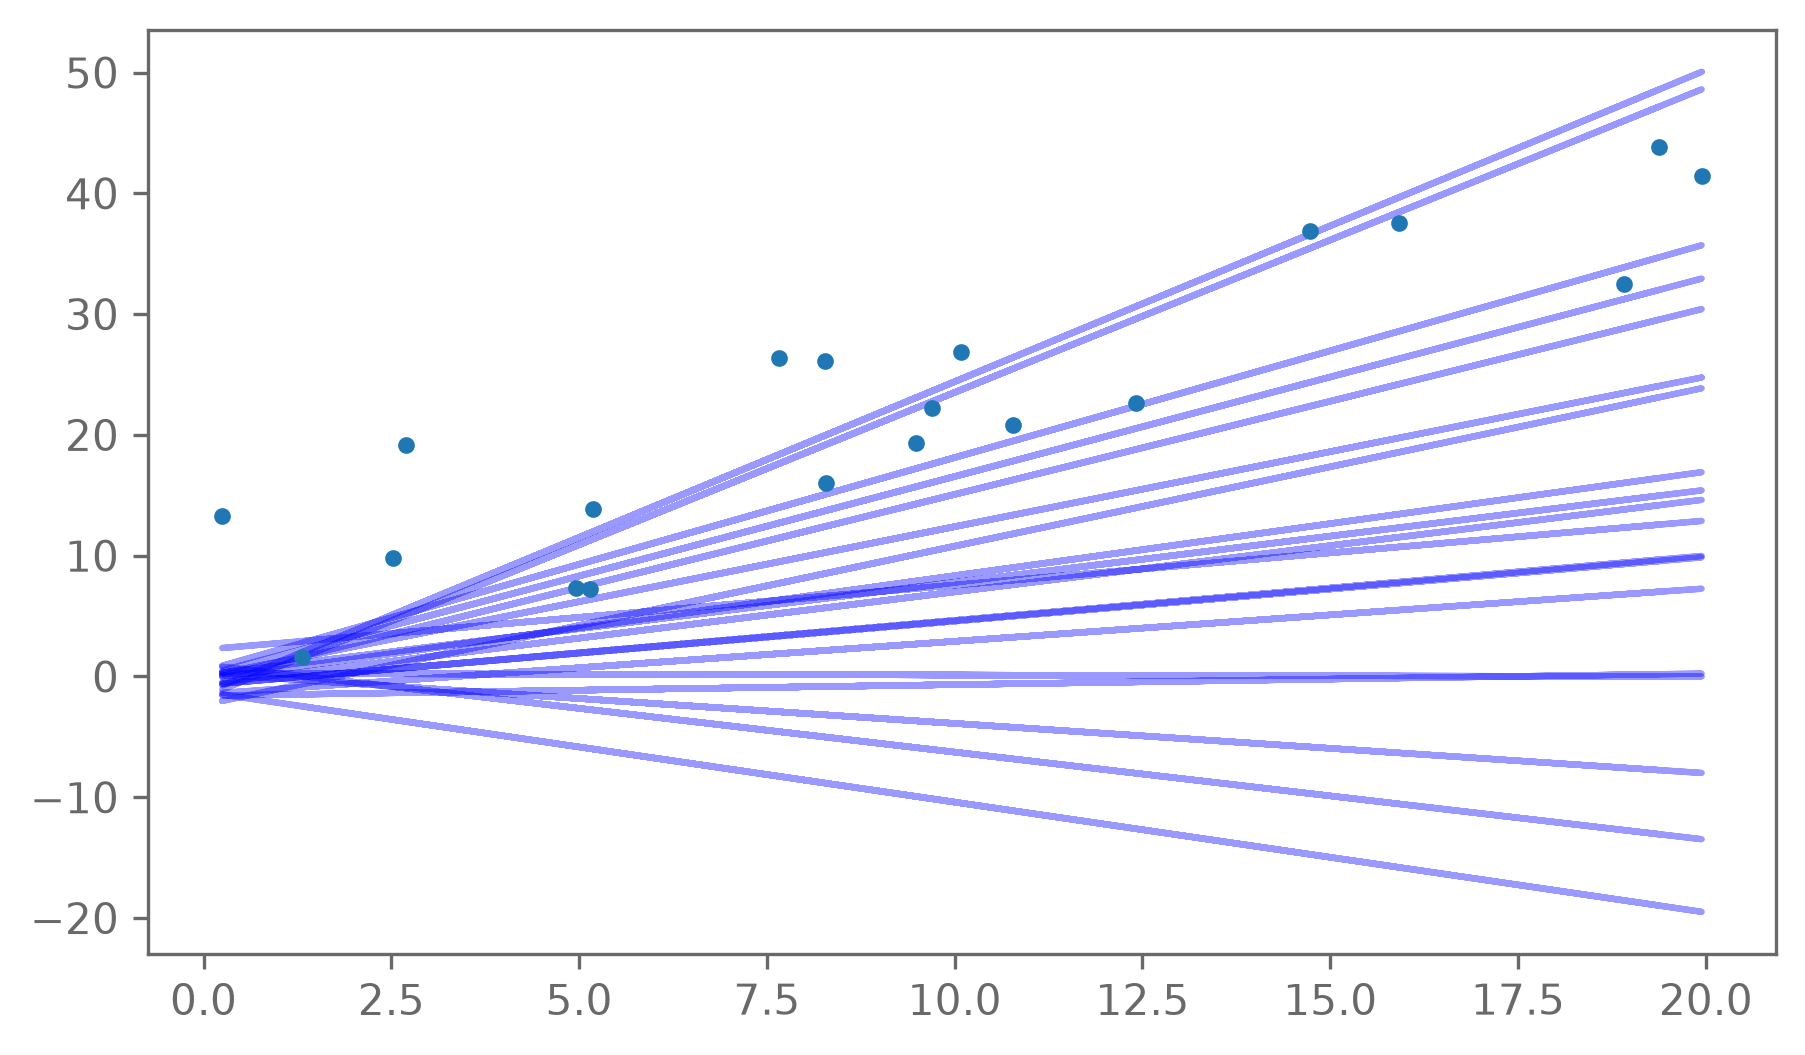

In [105]:
for n in range(1,len(prior_model_predictive)):
    plt.plot(x,prior_model_predictive[n], color="b",alpha=0.4)
plt.plot(x,y, ".")

### fitting model

In [108]:
def log_posterior_probability(m, b, x, sigma_y, y):
    return (
    log_likelihood_probability(y, m, b, x, sigma_y)
    + log_prior_probability(m, b)
    )
def negative_log_posterior(theta, x, sigma_y, y):
    m, b = theta
    return -log_posterior_probability(m, b, x, sigma_y, y)

In [116]:
MAP_result = scipy.optimize.minimize(
fun=negative_log_posterior,
x0=(1, 0),
args=(x, yerr, y)
)
m_MAP, b_MAP = MAP_result.x
m_true = 2
b_true = 3
print("MAP results")
print(f"m_MAP = {m_MAP:.3f}, b_MAP = {b_MAP:.3f}")
print(f"m_true = {m_true:.3f}, b_true = {b_true:.3f}")

MAP results
m_MAP = 2.063, b_MAP = 1.682
m_true = 2.000, b_true = 3.000


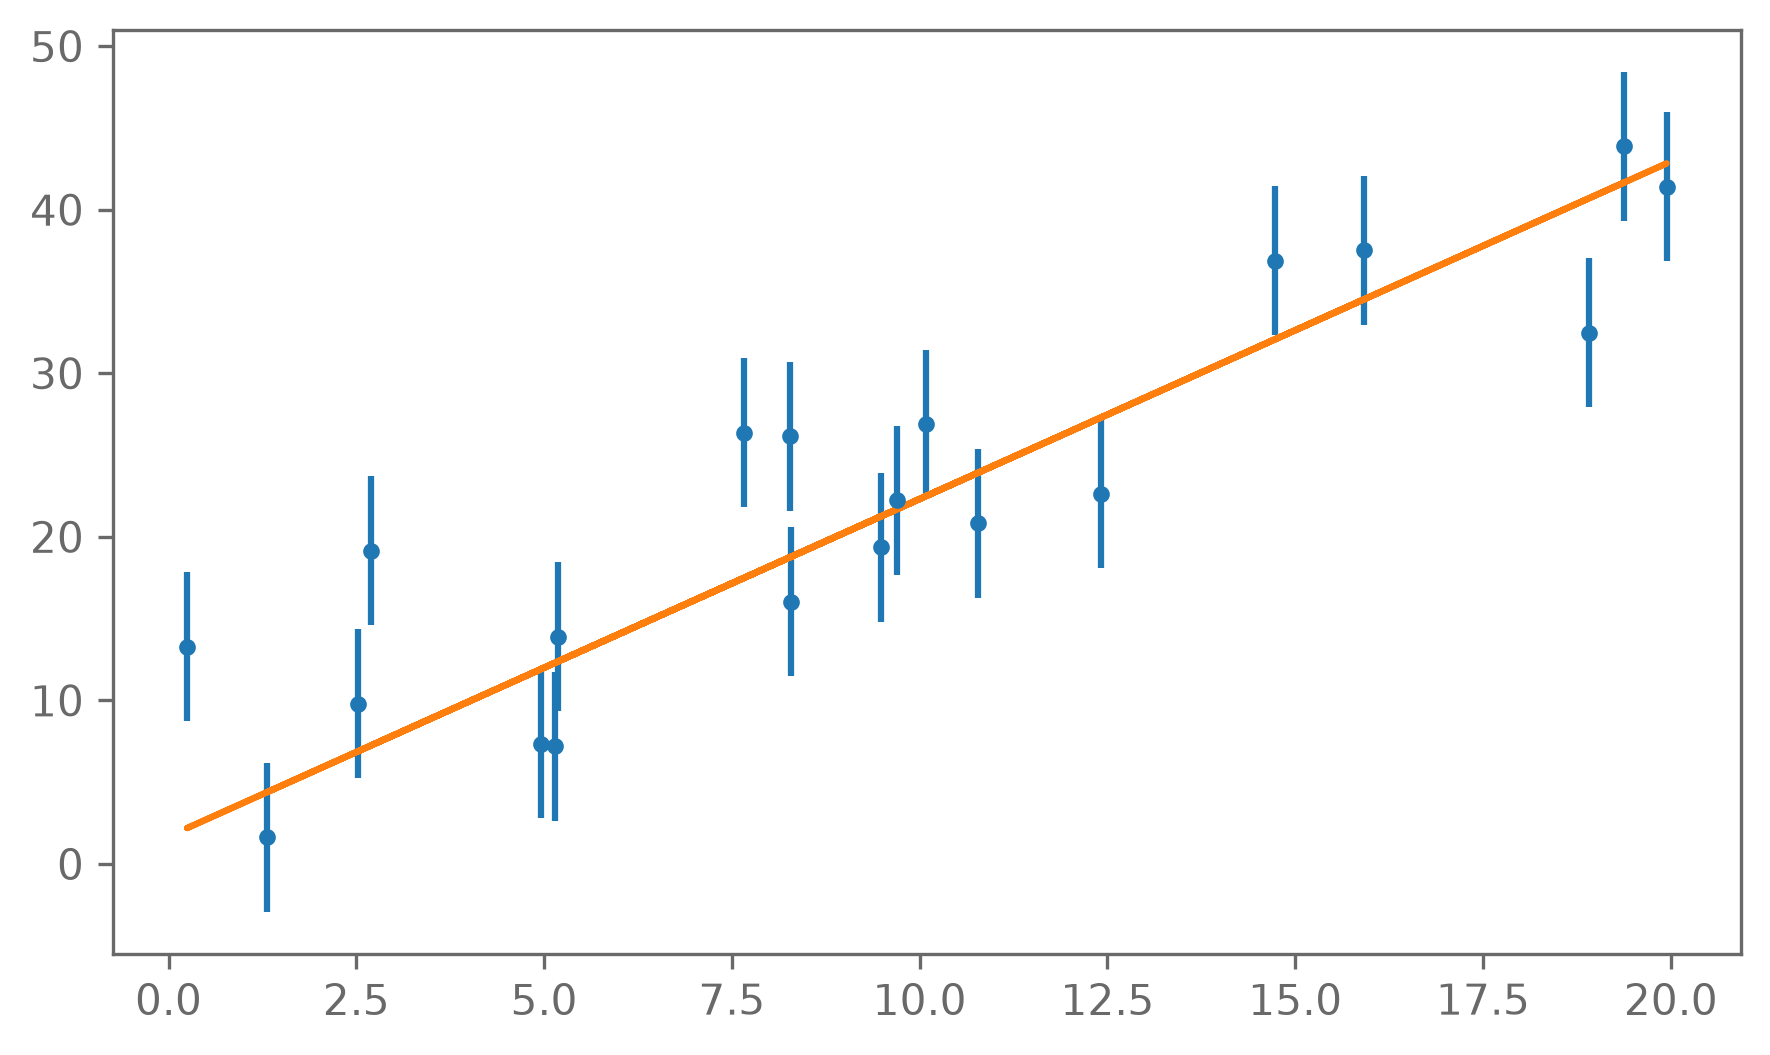

In [115]:
plt.errorbar(x,y,yerr=yerr, fmt=".", label="data")
plt.plot(x,model(m_MAP,b_MAP, x), label="model MAP")

### Posterior sampling

In [19]:
import emcee

In [ ]:
def log_posterior_wrapper(theta, x, sigma_y, y):
    m, b = theta
    return log_posterior_probability(m, b, x, sigma_y, y)

# emcee requires some extra settings to run
n_param = 2       # Number of parameter we are sampling
n_walker = 10     # Number of walkers. This just needs to be
                  # larger than 2*n_param + 1!  is the nr of mcmc-chains run simulatneously
n_step = 5000     # How many steps each walker will take. The number
                  # of samples will be n_walker*n_step

# The starting point for each walker
theta_init = np.array([0.5, 0.5]) \
    + 0.1*np.random.normal(size=(n_walker, n_param))
sampler = emcee.EnsembleSampler(
    nwalkers=n_walker, ndim=n_param,
    log_prob_fn=log_posterior_wrapper,
    args=(x, yerr, y)
)
state = sampler.run_mcmc(theta_init, nsteps=n_step)

In [124]:
# The samples will be correlated, this checks how correlated they are
# We will discuss this once we come to MCMC methods
print("Auto-correlation time:")
for name, value in zip(["m", "b", "f"], sampler.get_autocorr_time()):
    print(f"{name} = {value:.1f}")
# We need to discard the beginning of the chain (a few auto-correlation times)
# to get rid of the initial conditions
chain = sampler.get_chain(discard=300, thin=10, flat=True)

Auto-correlation time:
m = 44.4
b = 35.6


In [125]:
print("Posterior results (mean±std)")
print(f"m = {np.mean(chain[:,0]):.2f}±{np.std(chain[:,0]):.2f}")
print(f"b = {np.mean(chain[:,1]):.2f}±{np.std(chain[:,1]):.2f}")


Posterior results (mean±std)
m = 2.06±0.12
b = 1.69±1.01


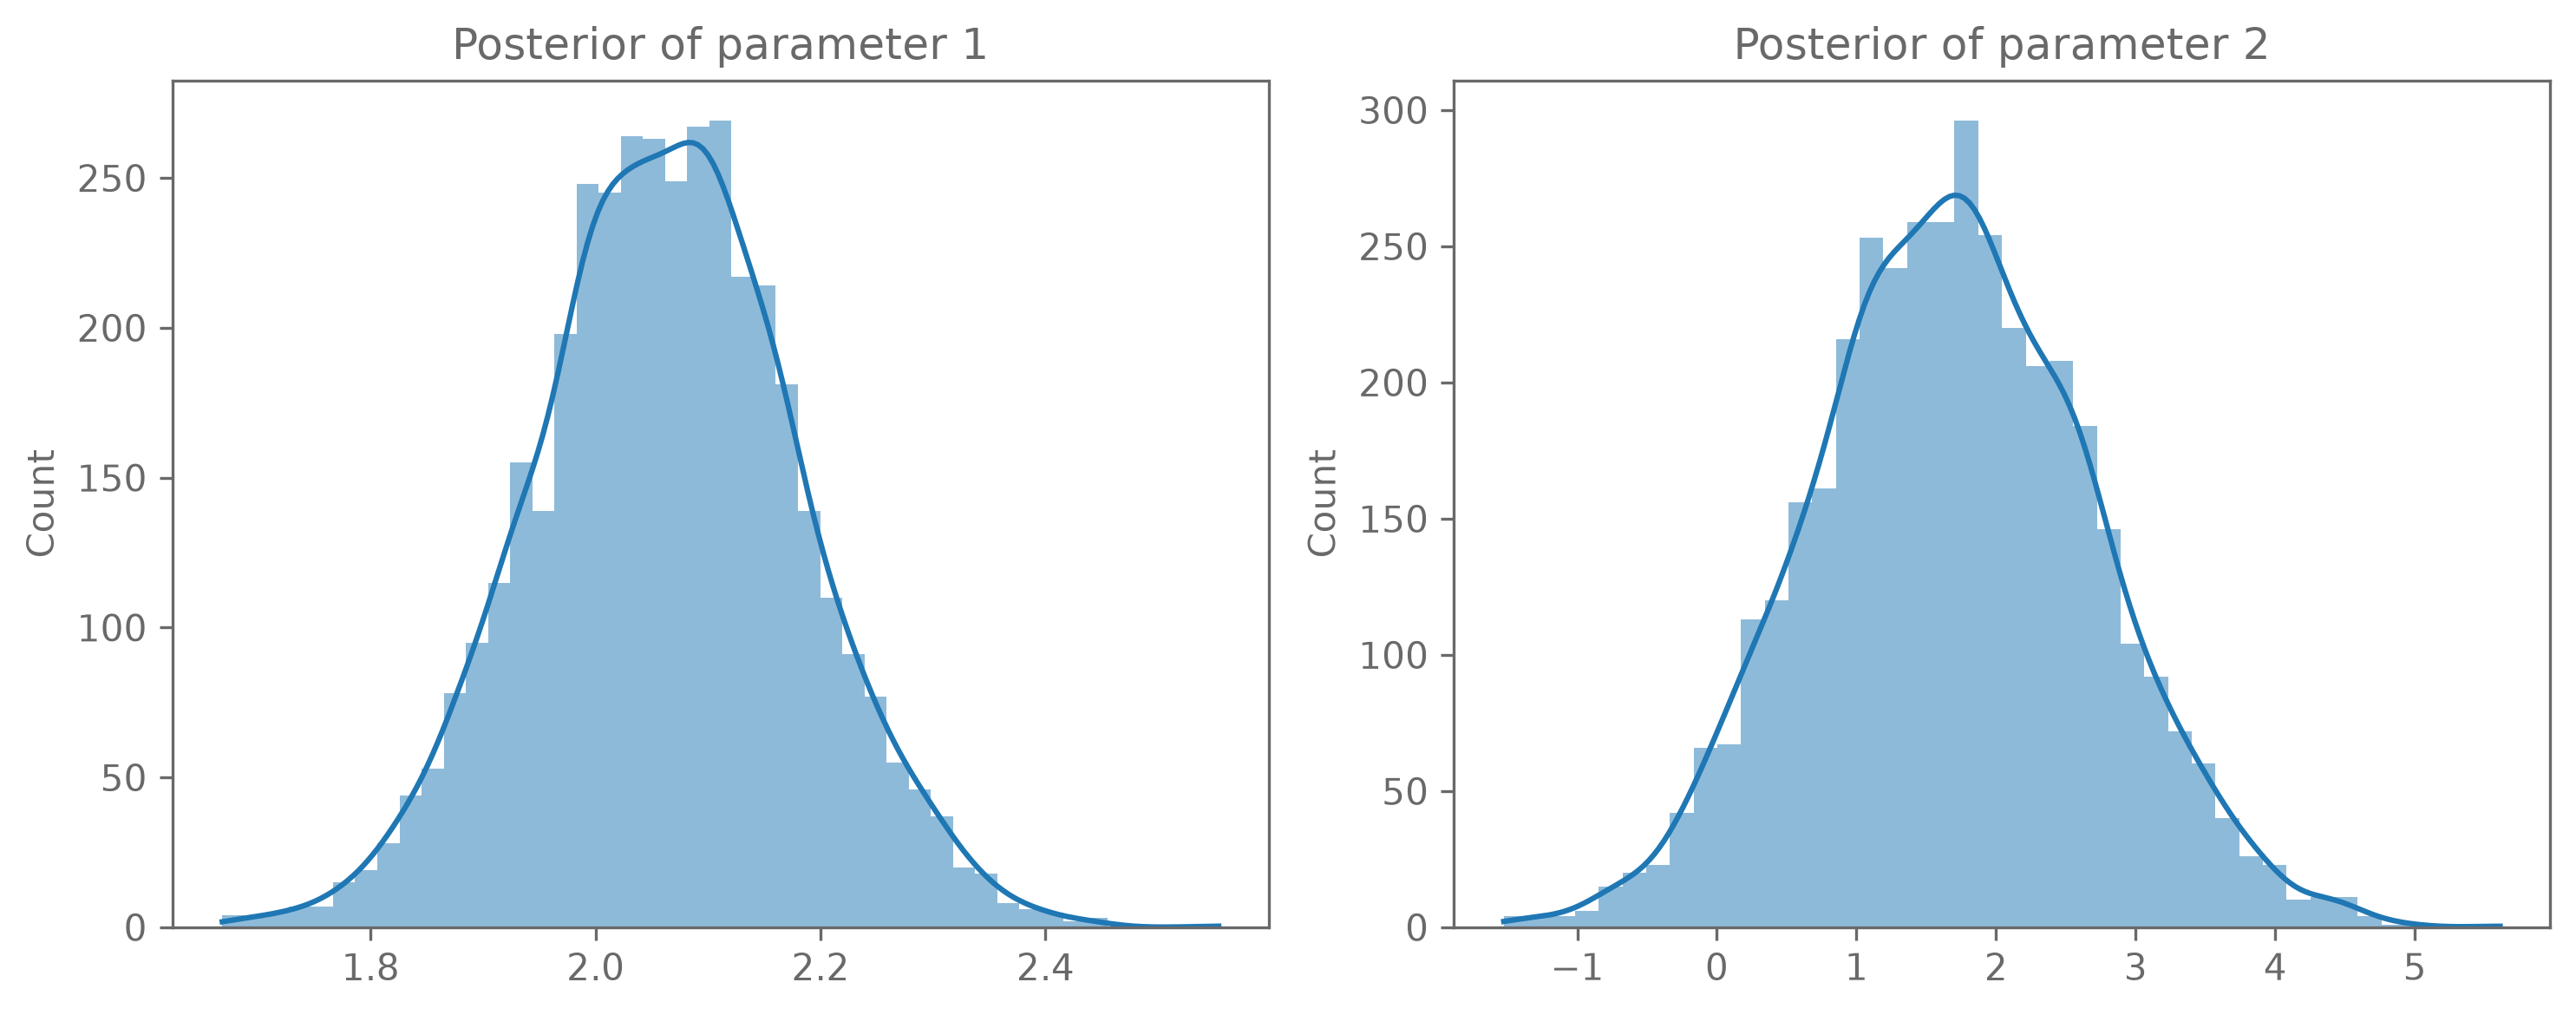

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
flat_samples = sampler.get_chain(discard=1000, thin=10, flat=True)
# shape: (N_samples, n_param)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(flat_samples[:,0], kde=True, ax=axes[0])
axes[0].set_title("Posterior of parameter 1")

sns.histplot(flat_samples[:,1], kde=True, ax=axes[1])
axes[1].set_title("Posterior of parameter 2")

plt.tight_layout()
plt.show()


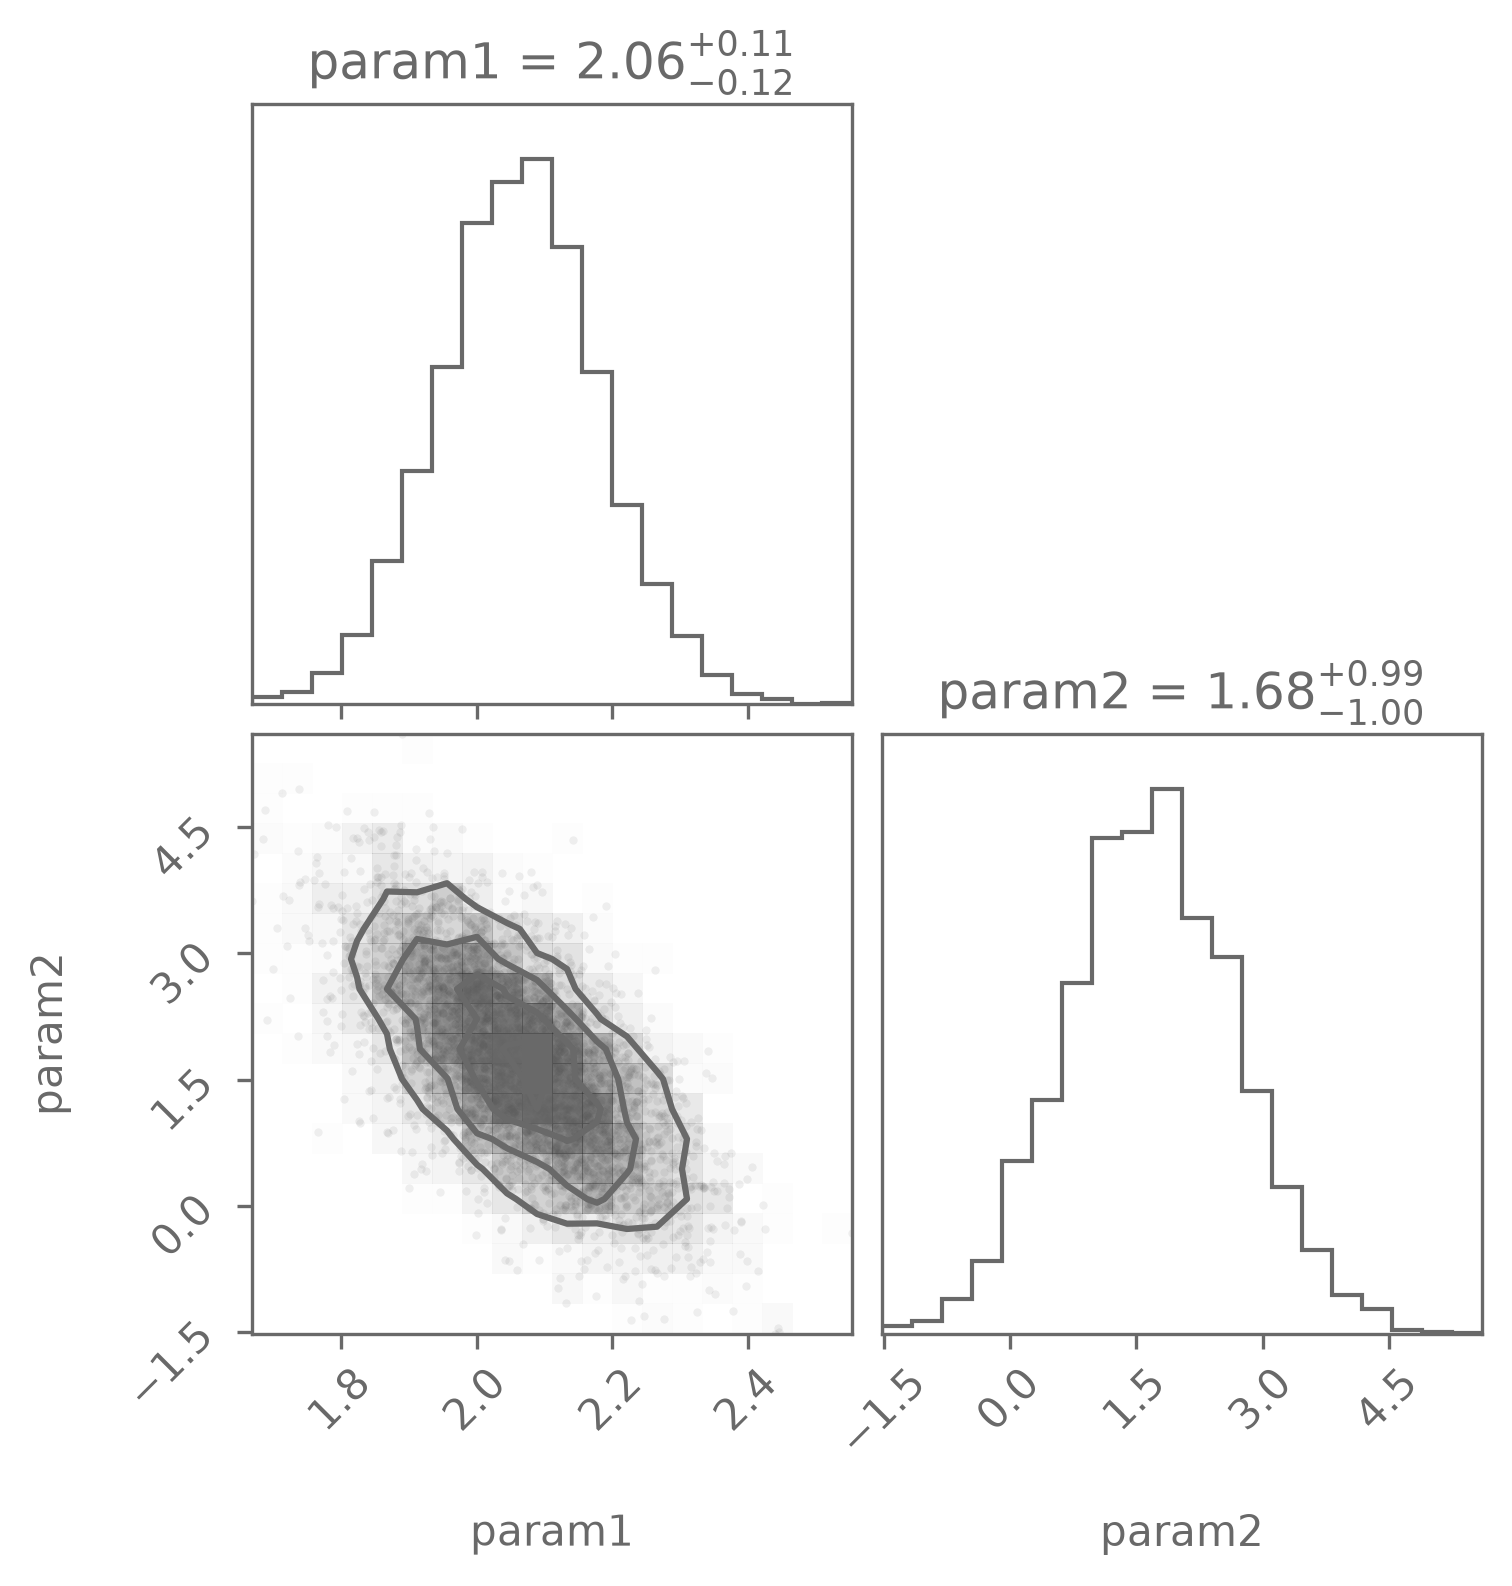

In [129]:
import corner

figure = corner.corner(
    flat_samples,
    labels=["param1", "param2"],
    show_titles=True
)


## Ex1 with new data

In [3]:
x,y,yerr=np.loadtxt("data/linear_fits/data_1.txt", unpack=True)

<ErrorbarContainer object of 3 artists>

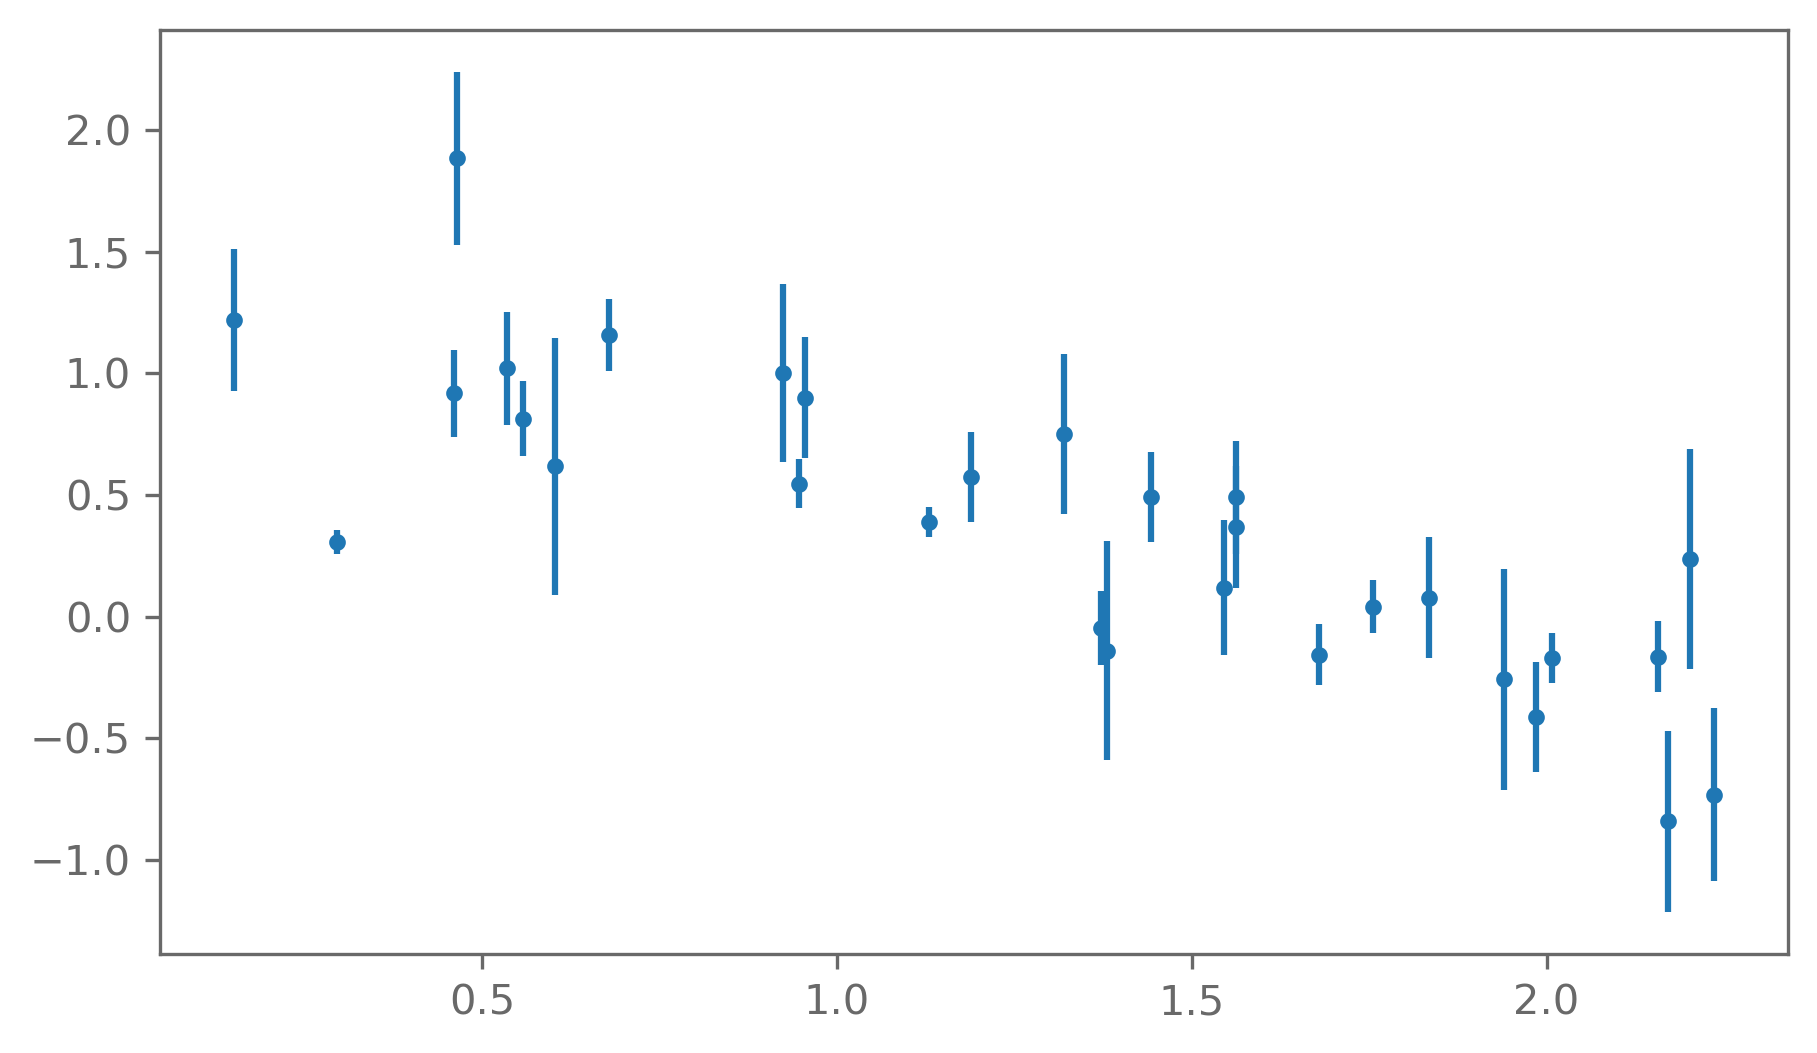

In [5]:
plt.errorbar(x,y,yerr=yerr, fmt=".")

In [34]:
def model(m,b,x):
    return m*x+b

def log_likelihood_prob_2(y,sigma_y,m,x,b):
    pred=model(m,b,x)

    logs= -0.5* (y-pred)**2 / sigma_y**2 - 0.5*np.log(2*np.pi*sigma_y**2)
    return np.sum(logs)
prior_m=scipy.stats.norm(loc=-1, scale=1) #set up function
prior_b=scipy.stats.norm(loc=1, scale=1)

def log_prior_prob_2(m,b):
    return prior_m.logpdf(m)+prior_b.logpdf(b) #.logpdf evaluates the log of the pdf at m and returns the value

def posterior_log_prob_2(x,y,sigma_y,m,b):
    return log_likelihood_prob_2(y,sigma_y, m,x,b) + log_prior_prob_2(m,b)

In [55]:
def sample_prior_2(n_sample):
    """Sample n_sample times from the prior distribution."""
    return np.vstack((prior_m.rvs(n_sample), prior_b.rvs(n_sample))).T #somehow the function otherwise won't accept it as a vector
    # bc the duo of numbers is then stored in 2 seperate arrays instead of 1 array with 2 values per random sample

# Fix the pseudo random number generator seed for reproducibility
np.random.seed(42)

# Evaluate the model at the prior sample parameters
prior_model_predictive = np.array(
    [model(*parameters, x) for parameters in sample_prior_2(n_sample=20)]
)

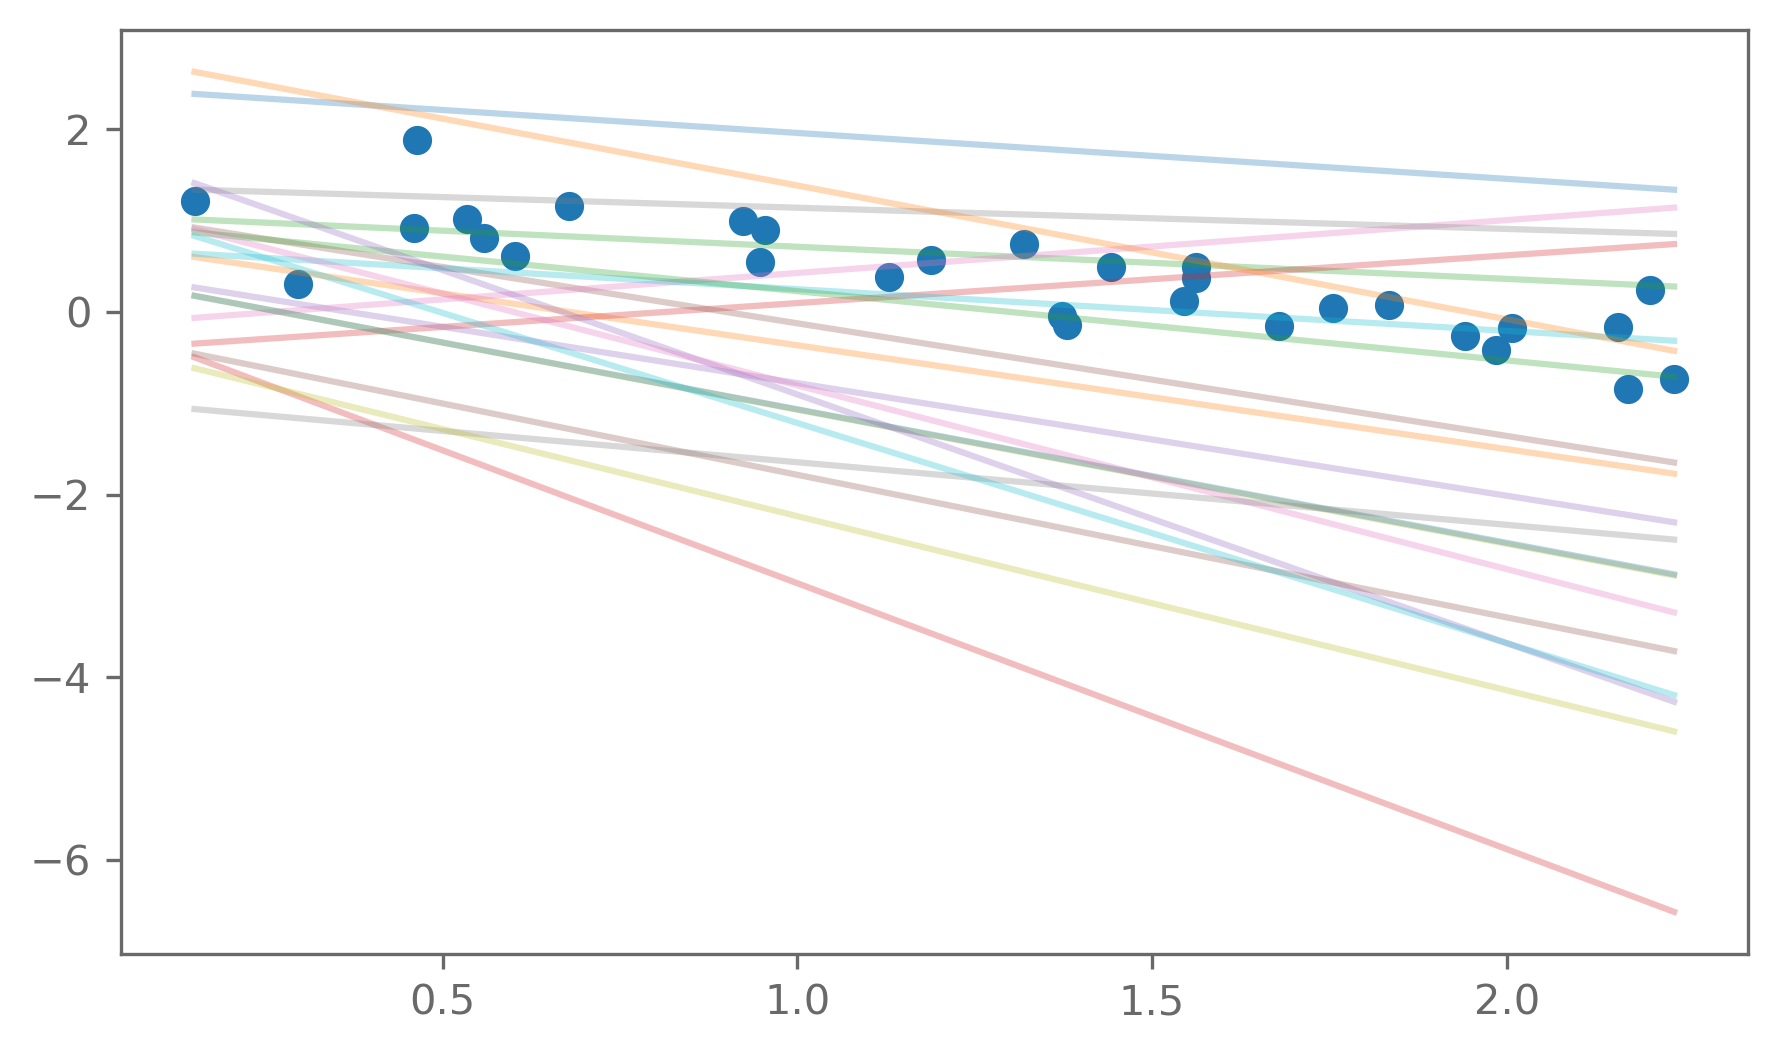

In [59]:
for i in range (0,len(prior_model_predictive)):
    plt.plot(x,prior_model_predictive[i], alpha=0.3)
plt.scatter(x,y)

In [65]:
def negative_log_posterior_prob_2(params,x,y,sigma_y):
    m,b =params
    return -1*posterior_log_prob_2(x,y,sigma_y, m,b)

MAP_result=scipy.optimize.minimize(
    fun=negative_log_posterior_prob_2,
    x0=[-3,2],
    args=(x,y,yerr)
)

In [66]:
MAP_result

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 49.72848899761802
        x: [-3.616e-01  6.997e-01]
      nit: 4
      jac: [-4.768e-07  9.537e-07]
 hess_inv: [[ 1.771e-03 -1.842e-03]
            [-1.842e-03  2.599e-03]]
     nfev: 18
     njev: 6

In [67]:
m_MAP, b_MAP = MAP_result.x
print("MAP results")
print(f"m_MAP = {m_MAP:.3f}, b_MAP = {b_MAP:.3f}")


MAP results
m_MAP = -0.362, b_MAP = 0.700


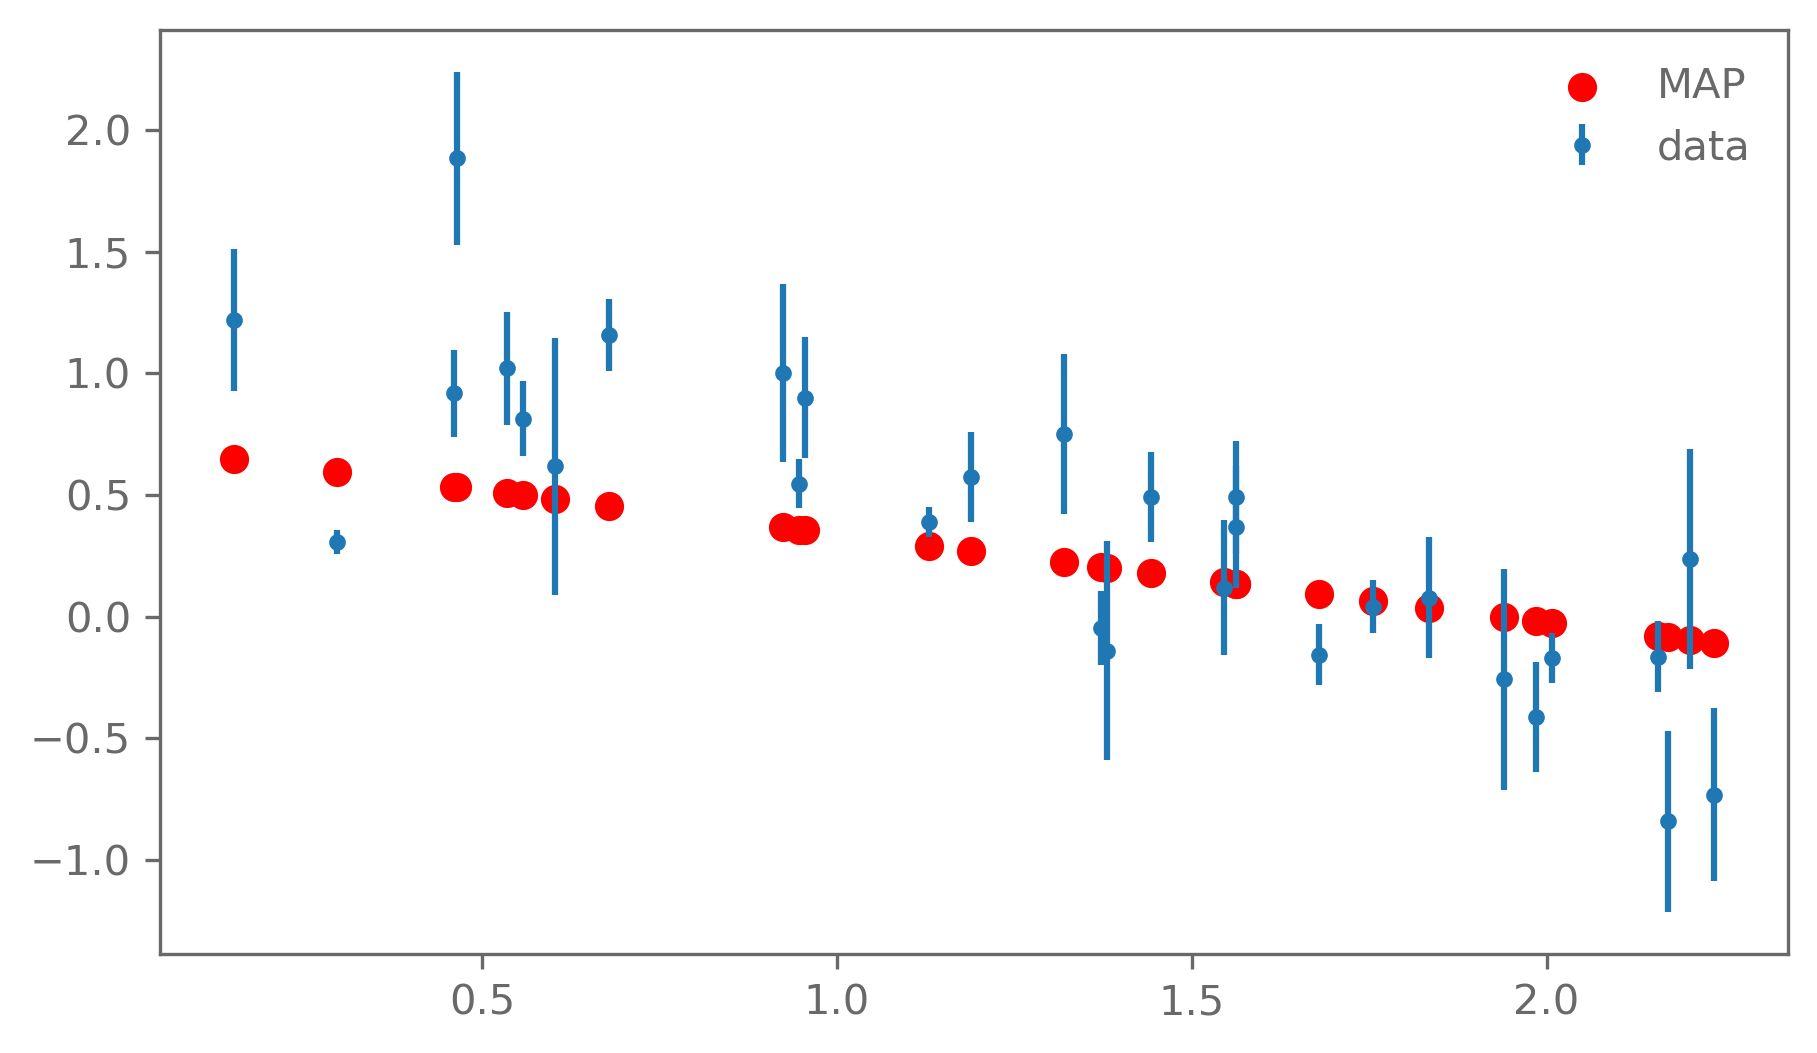

In [71]:
plt.errorbar(x,y, yerr=yerr,label="data", fmt=".")
plt.scatter(x,model(m_MAP,b_MAP,x), label="MAP", color="r")
plt.legend()